In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

df = pd.read_csv('../data/house_prices.csv')
print(df.shape)
df.head()

(2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [7]:
df = df[['Area', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price']].dropna()
pd.set_option('display.float_format', '{:.0f}'.format)


print("Dataset shape:", df.shape)
print("\nBasic stats:")
df.describe()

Dataset shape: (2000, 5)

Basic stats:


,Area,Bedrooms,Bathrooms,YearBuilt,Price
count,2000,2000,2000,2000,2000
mean,2786,3,3,1961,537677
std,1295,1,1,36,276429
min,501,1,1,1900,50005
25%,1653,2,2,1930,300098
50%,2833,3,3,1961,539254
75%,3888,4,4,1993,780086
max,4999,5,4,2023,999656


Correlation with Price:
Price        1
YearBuilt    0
Area         0
Bedrooms    -0
Bathrooms   -0
Name: Price, dtype: float64


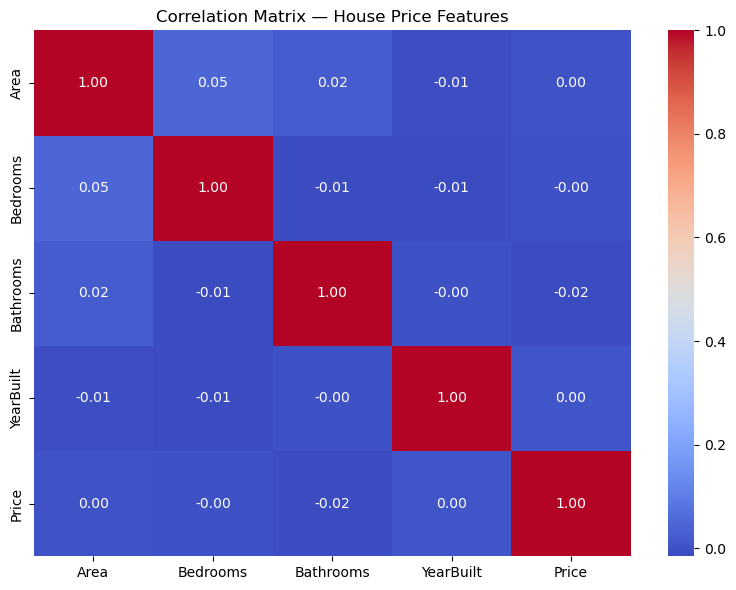

In [11]:
# Correlation matrix — shows relationship strength
correlation = df.corr()
print("Correlation with Price:")
print(correlation['Price'].sort_values(ascending=False).round(2))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix — House Price Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

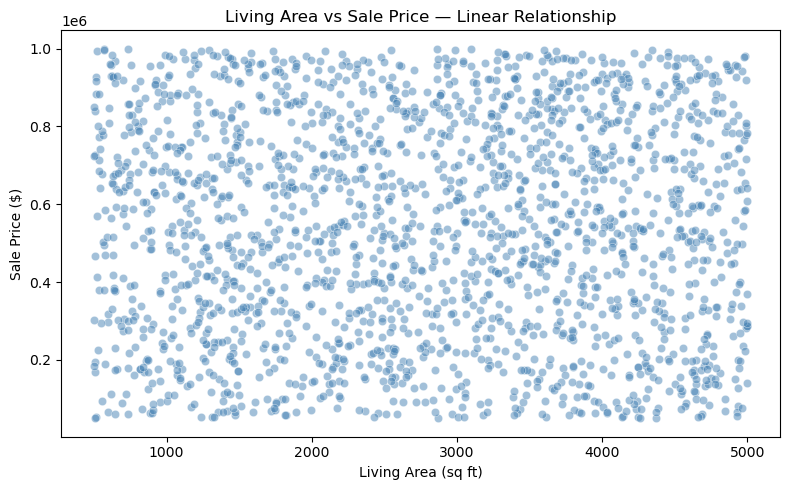

In [13]:
# Single variable — geometrical view of linear regression
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Area', y='Price', data=df, alpha=0.5, color='steelblue')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.title('Living Area vs Sale Price — Linear Relationship')
plt.tight_layout()
plt.savefig('scatter_plot.png')
plt.show()

In [24]:
# Cell 5 — OLS Simple Linear Regression (House Price)
import statsmodels.api as sm

data = df.dropna()
x = data['Area'].values
y = data['Price'].values

x_const = sm.add_constant(x)
results = sm.OLS(y, x_const).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                  0.004752
Date:                Fri, 03 Apr 2026   Prob (F-statistic):              0.945
Time:                        05:02:35   Log-Likelihood:                -27897.
No. Observations:                2000   AIC:                         5.580e+04
Df Residuals:                    1998   BIC:                         5.581e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.368e+05   1.47e+04     36.588      0.000    5.08e+05    5.66e+05
x1             0.3291      4.775      0.069      0.945      -9.035       9.693
==============================================================================
Omnibus:                     1641.242   Durbin-Watson:                   2.053
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              121.863
Skew:                          -0.064   Prob(JB):                     3.45e-27
Kurtosis:                       1.798   Cond. No.                     7.29e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.29e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

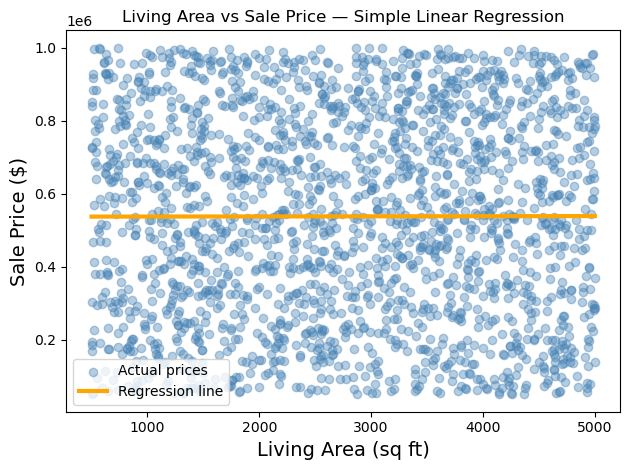


Intercept (β₀): 536759.8
Slope (β₁):     0.33

Interpretation: For every 1 sq ft increase in living area,
house price increases by $0.33


In [25]:
# Cell 6 — Geometrical Representation (House Price)
import numpy as np
import matplotlib.pyplot as plt

intercept = results.params[0]   # β₀ — base price
slope = results.params[1]       # β₁ — price per sq ft

x1 = np.linspace(min(x), max(x), 100)
yhat = slope * x1 + intercept

plt.scatter(x, y, alpha=0.4, color='steelblue', label='Actual prices')
plt.plot(x1, yhat, lw=3, c='orange', label='Regression line')
plt.xlabel('Living Area (sq ft)', fontsize=14)
plt.ylabel('Sale Price ($)', fontsize=14)
plt.title('Living Area vs Sale Price — Simple Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nIntercept (β₀): {round(intercept, 2)}")
print(f"Slope (β₁):     {round(slope, 2)}")
print(f"\nInterpretation: For every 1 sq ft increase in living area,")
print(f"house price increases by ${round(slope, 2)}")